# image Processing
![# image Processing](./support_files/session2&3.png)

*In this session we will see the basics of (bio-)image processing with python. This lab is self-explanatory and follows a "learning by doing" philosophy.*

## Instructions

This notebook contains detailed instructions on how to program a image processing pipeline, simply go through the instructions step by step and try to implement each step as best as you can

If you are stuck:
    - first think some more about the problem and see if you can get yourself unstuck
    - search on the internet (in particular Stack Overflow) for a solution to your problem
    - ask one of your collegues for help
    - ask to the teacher

Some exercises are labeled as <span style="color:lightgreen">BONUS</span> exercises and it is up to you whether you'd like to complete them. If things are going slowly, you may want to skip them and come back to them later

## Goals

Starting from image `neuroblastoma_5` `(1)` your main goal is:
- to find the best combination of image processing steps to obtain the best mask possibile

And then, you can try to:
- automatically count the number of cells detected in the mask (<span style="color:lightgreen">BONUS</span>)
- calculate the area of each cell (<span style="color:lightgreen">BONUS</span>)
- replicate the same study on image `neuroblastoma_14``(4)` (<span style="color:lightgreen">BONUS</span>)

(1)[<image src="./data/neuroblastoma_5_orig.jpg" width="250"/>](./data/neuroblastoma_5_orig.jpg)
(2)[<image src="./data/neuroblastoma_5_mask.png" width="250"/>](./data/neuroblastoma_5_mask.png)
(3)[<image src="./data/neuroblastoma_5_masked.jpg" width="250"/>](./data/neuroblastoma_5_masked.jpg)

image `(2)` is an example of the ideal mask for image `(1)` <br>
*(Do not worry if you can't get exactly this result, but do your best to get the best result you can)*

(4)[<image src="./data/neuroblastoma_14.jpg" width="250"/>](./data/neuroblastoma_14.jpg)
(5)[<image src="./data/neuroblastoma_14_mask.png" width="250"/>](./data/neuroblastoma_14_mask.png)

##  Table of Contents

1. [Importing Modules & Packages](#import)
2. [Load image Data](#load)
3. [Normalization](#norm)
4. [Filters](#filters)
5. [Image Arithmetic](#arith)
6. [Thresholding](#thresh)
7. [Measurements](#meas)

## 1. Importing Modules & Packages <a id=import></a>

In [414]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
from skimage import filters
from skimage import morphology
from skimage.io import imread

## 2. Load image Data <a id=load></a>

In [415]:
"""
Specify the file path
"""
# The image names is 'neuroblastoma_5.tif' and it is located in the folder 'data'
# You can:
# - declare the filepath variable as './data/imagename.tif'
# - or, better specify it using join function that automatically takes 
#    care of the slashes that need to be added when combining two paths:
#    os.path.join(folder name, image name)

### YOUR CODE HERE!
filepath = os.path.join('data', 'neuroblastoma_5.tif')


In [416]:
"""
Load the image
"""
# Use the function imread to read the image

### YOUR CODE HERE!
image = imread(filepath)

In [417]:
"""
See image info
"""
# 1. Check that 'image' is a variable of type 'ndarray'
# 2. Print the shape of the array by looking at its 'shape' attribute
# 3. See the datatype of the individual numbers in the array (attribute 'dtype')

### YOUR CODE HERE!
print("Loaded array is of type:", type(image))
print("Loaded array has shape:", image.shape)
print("Loaded values are of type:", image.dtype)

Loaded array is of type: <class 'numpy.ndarray'>
Loaded array has shape: (1024, 1280)
Loaded values are of type: uint8


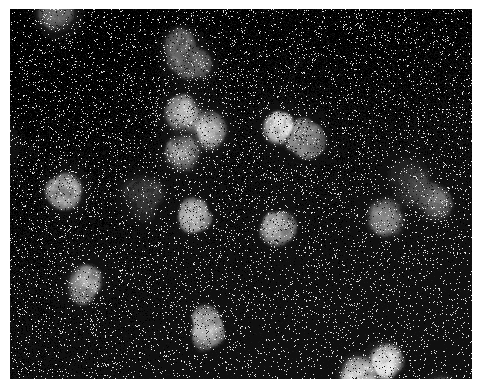

In [418]:
"""
Visualize the image
"""

### YOUR CODE HERE!
plt.figure()
plt.imshow(image, interpolation='none', cmap='gray')
plt.axis('off')
plt.show()

## 3. Normalization <a id=norm></a>

Before going ahead with our image analysis, we need to be sure that the image is exaclty as it seems. As we saw a couple of lines ago, this image is of type uint8, so we expect its values ​​to be in 0-255 range.

(0.0, 255.0)

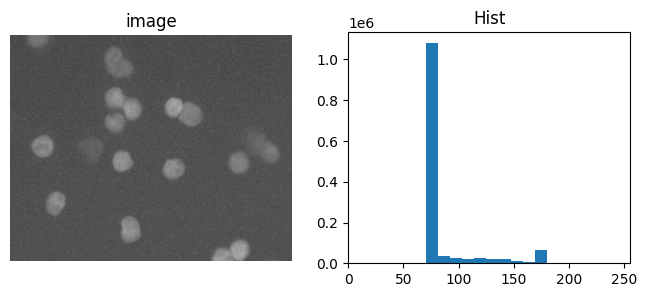

In [419]:
"""
Check the image values
"""
# Use this subplots to visualize the image (be sure that min and max values are the ones we want)
# and its histogram (also here, be sure that the x axis has the right range of values)

### YOUR CODE HERE!
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,3))
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.set_title('image')
ax1.axis('off')
ax2.hist(image.flatten())
ax2.set_title('Hist')
ax2.set_xlim(0, 255)

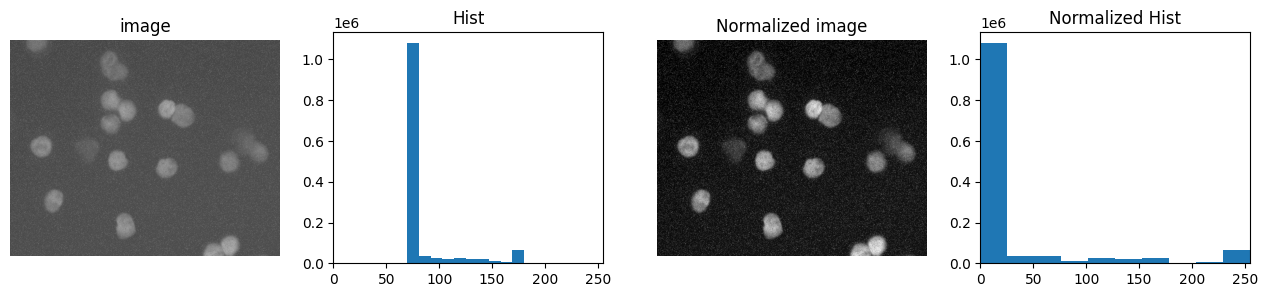

In [420]:
"""
If needed, normalize the image
"""
# If you noticed that the image is not exactly as you expected and that its values ​are 
# not distributed over the entire range 0-255, normalize the image on this range.

# Use the cv2.normalize function (remember that the image type has to be uint8)
#       (if you don't know how to use it, check it here:
#       https://www.tutorialspoint.com/how-to-normalize-an-image-in-opencv-python)
# and plot again the new image and its histogram (copy from above the subplot) 

### YOUR CODE HERE!
image_normalized = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8UC1)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16,3))
ax1.imshow(image, cmap='gray', vmin=0, vmax=255)
ax1.set_title('image')
ax1.axis('off')
ax2.hist(image.flatten())
ax2.set_title('Hist')
ax2.set_xlim(0,255)
ax3.imshow(image_normalized, cmap='gray', vmin=0, vmax=255)
ax3.set_title('Normalized image')
ax3.axis('off')
ax4.hist(image_normalized.flatten())
ax4.set_title('Normalized Hist')
ax4.set_xlim(0,255)
plt.show()

## 4. Filters <a id=filters></a>

Good job! Now, we have to worry about another problem of the image, its noise. <br>
In this section, apply all the different filters we have studied to your image, play a bit with the parameters and then choose the one that you think best solves our problem.

In [421]:
# At the beginning of each session, re-define your image variable
# as the output of the previous session to not mess with names.
# Just be aware that "image" variable will then be overwritten with your new corrected image.

image = image_normalized

### 4.1 Mean Filter

In [422]:
"""
Apply mean filter
"""
# Use the filters.rank.mean function 
#       (if you don't know how to use it, check it here:
#       - doc: https://scikit-image.org/docs/stable/api/skimage.filters.rank.html#skimage.filters.rank.mean
#       - examples: https://scikit-image.org/docs/stable/auto_examples/applications/plot_rank_filters.html)
# and play with the footprint/disk size

### YOUR CODE HERE!
size = 5
mean_image = filters.rank.mean(image.astype(np.uint8), morphology.disk(size))

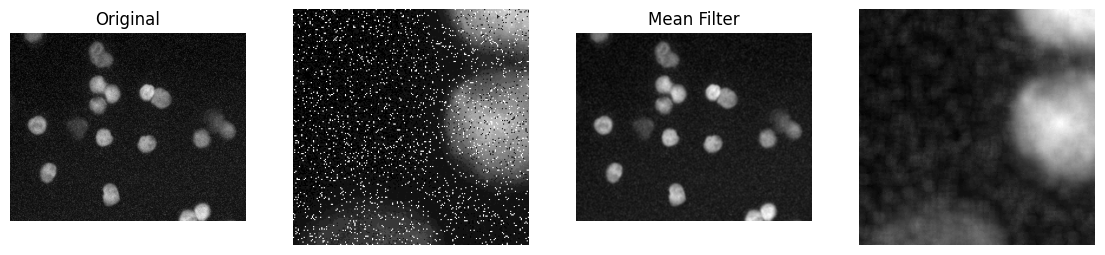

In [423]:
# Use this subplot to better visualize your results
# (image = starting image, mean_image = result of the mean function above)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(14,4))
ax1.imshow(image, cmap='gray')
ax1.axis('off')
ax1.set_title('Original')
ax2.imshow(image[300:500,300:500], cmap='gray')
ax2.axis('off')
ax3.imshow(mean_image, cmap='gray')
ax3.axis('off')
ax3.set_title('Mean Filter')
ax4.imshow(mean_image[300:500,300:500], cmap='gray')
ax4.axis('off')
plt.show()

### 4.2 Median Filter

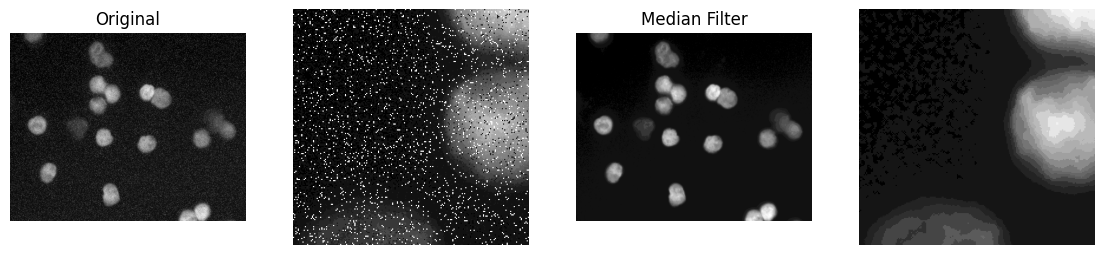

In [424]:
"""
Apply median filter
"""
# Use the filters.rank.median function 
#       (if you don't know how to use it, check it here:
#       - doc: https://scikit-image.org/docs/stable/api/skimage.filters.rank.html#skimage.filters.rank.median
#       - examples: https://scikit-image.org/docs/stable/auto_examples/applications/plot_rank_filters.html)
# and play with the footprint/disk size

# Use the same subplot as above to vizulize your results

### YOUR CODE HERE!
size = 2
median_image = filters.median(image, morphology.disk(size))

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(14,4))
ax1.imshow(image, cmap='gray')
ax1.axis('off')
ax1.set_title('Original')
ax2.imshow(image[300:500,300:500], cmap='gray')
ax2.axis('off')
ax3.imshow(median_image, cmap='gray')
ax3.axis('off')
ax3.set_title('Median Filter')
ax4.imshow(median_image[300:500,300:500], cmap='gray')
ax4.axis('off')
plt.show()

### 4.3 Gaussian Filter

How much the image is smoothed by a Gaussian kernel is determined by the standard deviation of the Gaussian distribution, usually referred to as `sigma` ($\sigma$). A higher $\sigma$ means a broader distribution and thus more smoothing.

**How to choose the correct value of $\sigma$?**

This depends a lot on your images, in particular on the pixel size. In general, the chosen $\sigma$ should be large enough to blur out noise but small enough so the "structures of interest" do not get blurred too much. Usually, the best value for $\sigma$ is simply found by trying out some different options and looking at the result.

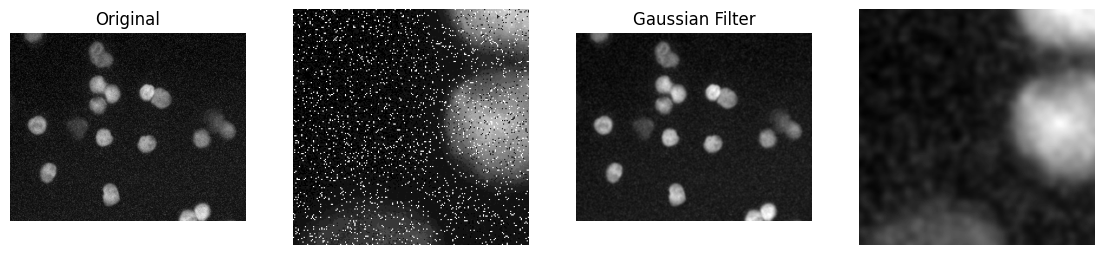

In [425]:
"""
Apply Gaussian filter
"""
# Use the ndi.gaussian_filter function 
#       (if you don't know how to use it, check it here:
#       https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.gaussian_filter.html)
# and play with sigma value

# Use the same subplot as above to vizulize your results

### YOUR CODE HERE!
sigma = 3
gaussian_image = ndi.gaussian_filter(image_normalized, sigma)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(14,4))
ax1.imshow(image, cmap='gray')
ax1.axis('off')
ax1.set_title('Original')
ax2.imshow(image[300:500,300:500], cmap='gray')
ax2.axis('off')
ax3.imshow(gaussian_image, cmap='gray')
ax3.axis('off')
ax3.set_title('Gaussian Filter')
ax4.imshow(gaussian_image[300:500,300:500], cmap='gray')
ax4.axis('off')
plt.show()

## 5. Image Arithmetic <a id=arith></a>

Great, at this point your image is almost ready to generate a good mask with the right thresold method.<br>
But, before, we can try to play with some arithmetic operations.

In [426]:
# At the beginning of each session, re-define your image variable
# as the output of the previous session to not mess with names.
# Just be aware that "image" variable will then be overwritten with your new corrected image.

image = median_image

________________________________________________________________

In [427]:
"""
Try to add and subtract one image to another
"""
# This part will not be helpful for your final goal, bit try to add your image to a new image to see
# how the look!

# The new imaga name is 'neuroblastoma_14.tif', open it as you did for 'neuroblastoma_5.tif'
# at the beginning
# Then, use cv2.add and cv2.subtract functions
#       (if you don't know how to use it, check it here:
#       https://www.geeksforgeeks.org/arithmetic-operations-on-images-using-opencv-set-1-addition-and-subtraction/)

### YOUR CODE HERE!
image2 = imread(os.path.join('data', 'neuroblastoma_14.tif'))
"""
image2 = cv2.resize(image2, (image.shape[1], image.shape[0]))
print(image.shape)
print(image2.shape)
"""

added = cv2.add(image, image2)
subtracted = cv2.subtract(image, image2)

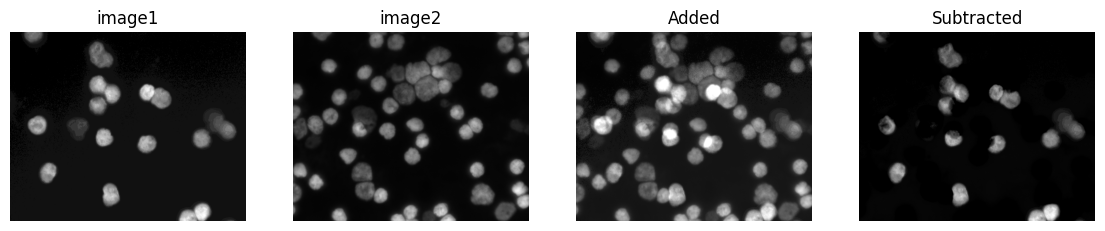

In [428]:
# Use this subplot to better visualize your results

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(14,4))
ax1.imshow(image, cmap='gray')
ax1.set_title('image1')
ax1.axis('off')
ax2.imshow(image2, cmap='gray')
ax2.set_title('image2')
ax2.axis('off')
ax3.imshow(added, cmap='gray')
ax3.set_title('Added')
ax3.axis('off')
ax4.imshow(subtracted, cmap='gray')
ax4.set_title('Subtracted')
ax4.axis('off')
plt.show()

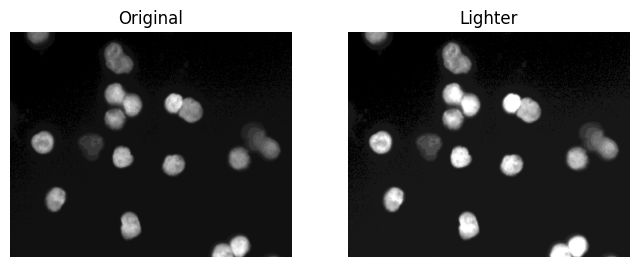

In [429]:
"""
Try to add light to your image
"""
# Using cv2.add function, add light to your image by increasing it with some constant value
# (generate a homogeneous image of this value with np.ones function multiplied by the constant value)
# and visulize the old image vs new image in a subplot

### YOUR CODE HERE!
light = np.ones(image.shape, dtype="uint8") * 80
lighter_image = cv2.add(image, light)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))
ax1.imshow(image, cmap='gray')
ax1.set_title('Original')
ax1.axis('off')
ax2.imshow(lighter_image, cmap='gray')
ax2.set_title('Lighter')
ax2.axis('off')
plt.show()


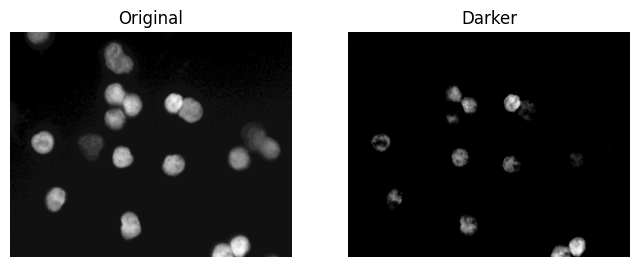

In [430]:
"""
Try to remove light to your image
"""
# Using cv2.subtraction function, remove light to your image, as before
# and visulize the old image vs new image in a subplot

### YOUR CODE HERE!
dark = np.ones(image.shape, dtype="uint8") * 120
darker_image = cv2.subtract(image, dark)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))
ax1.imshow(image, cmap='gray')
ax1.set_title('Original')
ax1.axis('off')
ax2.imshow(darker_image, cmap='gray')
ax2.set_title('Darker')
ax2.axis('off')
plt.show()

## 6. Thresholding <a id=thresh></a>

Amazing! :) We can now go into thresholding part. Here you have to create your best mask! <br>

In [431]:
# At the beginning of each session, re-define your image variable
# as the output of the previous session to not mess with names.
# Just be aware that "image" variable will then be overwritten with your new corrected image.

# WARNING: in this case, I suggest you to use the last image defined (from "Filters" section)
# because the Arithmentic Operations output have changed values and it is more diffcult 
# to work on them at this stage without further filters.

image = median_image

________________________________________________________________

### 6.1 Manual Thresholding

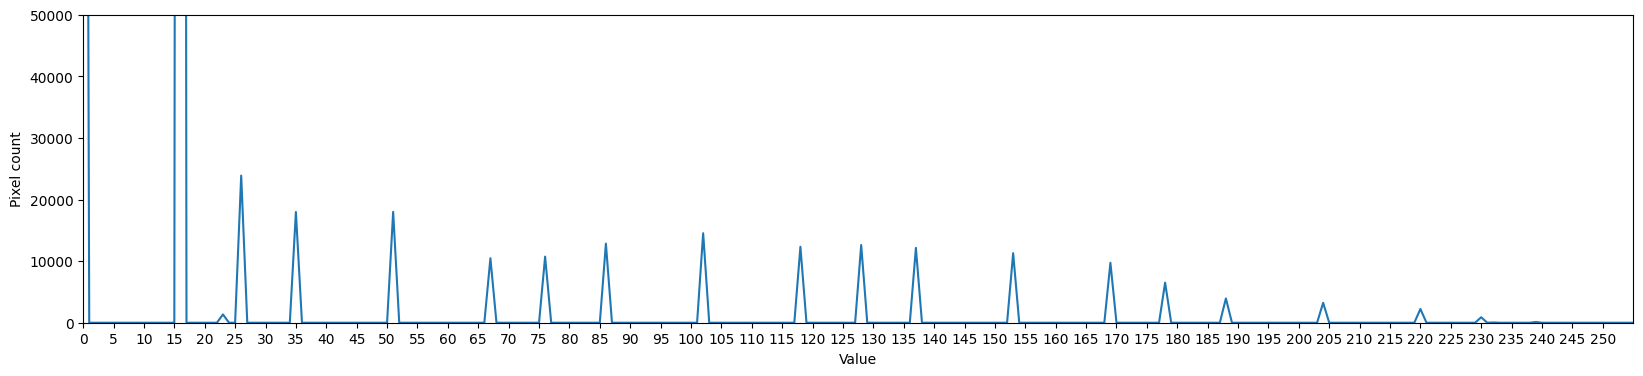

In [432]:
"""
Check the image values
"""
# Before thresholding manually your image you need to study its values.
# Plot the histigram of the image and try to guess the best value to threshold it.

### YOUR CODE HERE!
plt.figure(figsize=(20,4))
plt.xlim([0, 255])
plt.ylim([0,50000])
histogram, bin_edges = np.histogram(image, bins=256, range=(0, 256))
plt.plot(bin_edges[0:-1], histogram)
plt.xticks(np.arange(0,255, 5))
plt.xlabel("Value")
plt.ylabel("Pixel count")
plt.show()

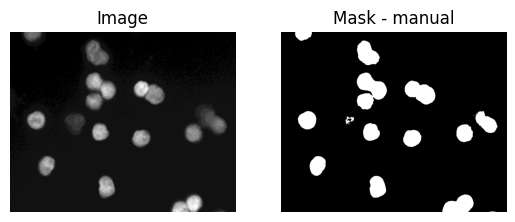

In [433]:
"""
Perfom manual thresholding
"""
# Define thresh variable for the the manual thresholding (integer value)
# and then try to change and adapt it based on the image result.

# Remember that you can use relational (Boolean) expressions such as 'smaller' (<), 'equal' (==)
# or 'greater or equal' (>=) with numpy arrays - and you can directly assign the result to a new
# variable (eg. manual_th)

# Visualize the original image with the mask resul in a subplot

### YOUR CODE HERE!
thresh = 60
manual_th = image > thresh

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(image, cmap='gray')
ax1.set_title('Image')
ax1.axis('off')
ax2.imshow(manual_th, cmap='gray')
ax2.set_title('Mask - manual')
ax2.axis('off')
plt.show()


### 6.2 Threshold detection

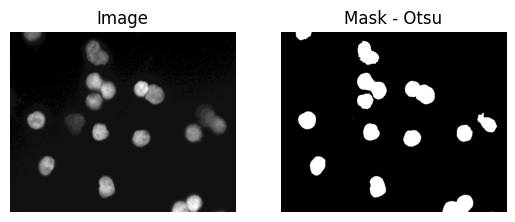

In [434]:
"""
Automatic threshold detection
"""
# The skimage.filters module 'thresholding' provides several threshold detection algorithms.
# The most popular one it's Otsu's method, so test it using 'threshold_otsu' function
#       (if you don't know how to use it, check it here:
#       https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_thresholding.html)
# and visualize the result as above.

### YOUR CODE HERE!
thresh = filters.thresholding.threshold_otsu(image)
otsu_th = image > thresh

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(image, cmap='gray')
ax1.set_title('Image')
ax1.axis('off')
ax2.imshow(otsu_th, cmap='gray')
ax2.set_title('Mask - Otsu')
ax2.axis('off')
plt.show()

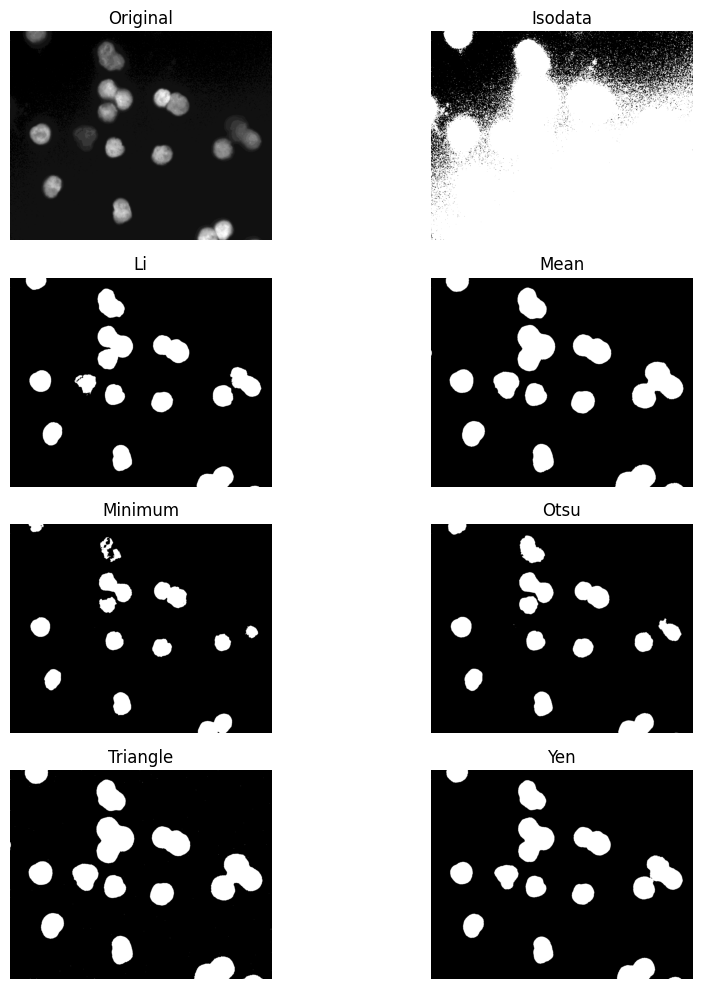

In [435]:
"""
Try them all!
"""
# The scikit-image module 'skimage.filters.thresholding' also provides 
# "try_all_threshold" function to test all the threshold methods available.
# Try it!
# The most popular one it's Otsu's method, so test it using 'threshold_otsu' function


### YOUR CODE HERE!
filters.thresholding.try_all_threshold(image, figsize=(10,10), verbose=False)
plt.show()

thresh =  filters.thresholding.threshold_li(image)
li_th = image > thresh

thresh =  filters.thresholding.threshold_yen(image)
yen_th = image > thresh

### 6.3 Adaptive Thresholding

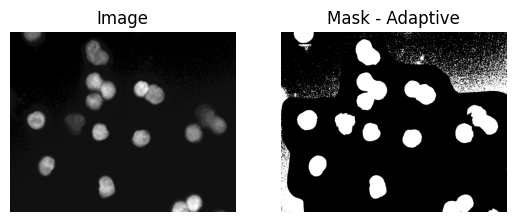

In [447]:
"""
Apply adaptive thresholding
"""
# Try the adaptive thresholding methods from cv2.adaptiveThreshold function.
#       (if you don't know how to use it, check it here:
#       https://docs.opencv2.org/4.x/d7/d1b/group__imgproc__misc.html#ga72b913f352e4a1b1b397736707afcde3)
# and play with the blockSize and C params to see the differences
# and visualize the result as above (subplot with original image and mask)

### YOUR CODE HERE!
adaptive_th = cv2.adaptiveThreshold(image, maxValue = 255, 
                            adaptiveMethod = cv2.ADAPTIVE_THRESH_MEAN_C, 
                            thresholdType = cv2.THRESH_BINARY,
                            blockSize = 281,
                            C = 0)

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(image, cmap='gray')
ax1.set_title('Image')
ax1.axis('off')
ax2.imshow(adaptive_th, cmap='gray')
ax2.set_title('Mask - Adaptive')
ax2.axis('off')
plt.show()

________________________________________________________________

Arrived at this point you should have obtained a valid mask of your image.<br>
*Note that if the best one for you is one of the "try_all_threshold", you can obtain it by applying the correspondant threshold method from 'skimage.filters.thresholding'.*

Now you can decide whether to replicate the study on the second image available (or, if you feel brave, on one of the other images in the "data" folder, to see what happens)

OR

continue with the bonus exercises below that will make you discover and learn new things.

Good luck! :)

## 7. Measurements <a id=meas></a> - <span style="color:lightgreen">BONUS</span>

In [437]:
mask = li_th


18


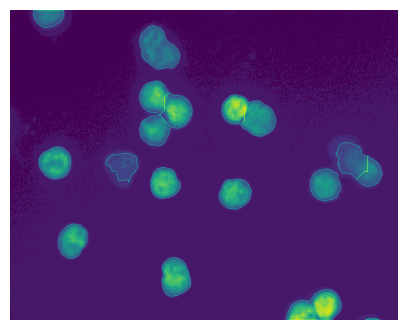

In [438]:
"""
Differentiate the cells in the mask
"""

from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from cellpose import utils


distance = ndi.distance_transform_edt(mask)
coords = peak_local_max(distance, footprint=np.ones((70, 70)), labels=mask)
watmask = np.zeros(distance.shape, dtype=bool)
watmask[tuple(coords.T)] = True
markers, _ = ndi.label(watmask)
labels = watershed(-distance, markers, mask=mask)

print(len(np.unique(labels))-1)

image_copy = image.copy()
outlines = utils.masks_to_outlines(labels)
outX, outY = np.nonzero(outlines)
image_copy[outX, outY] = 255

plt.figure(figsize=(5,5))
plt.imshow(image_copy)
plt.axis('off')
plt.show()


In [448]:
areas = []

for i in np.unique(labels):
    if i > 0:
        maski = np.zeros(image.shape)
        maski[labels == i] = 255
        area = np.count_nonzero(maski)
        areas.append(area)

print(round(np.mean(areas),2))

2732.28
